<a href="https://colab.research.google.com/github/jihyejung-400/public/blob/master/%ED%8C%8C%EC%9D%B4%EC%8D%AC%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D%EA%B8%B0%EC%B4%88(2026)_%EC%98%A8%EC%8B%A4%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D%ED%95%B4%EB%B3%B4%EA%B8%B0_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 데이터 준비하기

1. 강의자료에서 데이터 받기: [강의자료 링크](https://project.taegon.kr/rda-ml-2026)
1. 드래그해서 올리기
1. 아래 코드로 압축풀기


In [6]:
!unzip -q 'data_smartfarm.zip' -d '농촌진흥청_스마트팜 현장 농가 데이터_20220822'

## 한글 폰트 설정하기 (그래프)

In [7]:
!pip install -q koreanize-matplotlib
import koreanize_matplotlib        #metplotlib 사용시 한글폰트 안깨지게 설정

## 데이터 불러오기

In [9]:
import os
import pandas as pd
import glob
import tqdm

base_dir = './농촌진흥청_스마트팜 현장 농가 데이터_20220822'

data = {
    '환경': {},
    '생육': {},
    '생산': {},
    '재배정보': {}
}

years = ['2018', '2019', '2020', '2021']

for year in (pbar:= tqdm.tqdm(years, desc="연도별 자료 읽기")):
    pbar.set_postfix_str(year)
    year_dir = os.path.join(base_dir, year)

    if not os.path.exists(year_dir):
        print(f"{year} 디렉토리가 존재하지 않습니다.")
        continue

    # 1. 환경 데이터 (CSV)
    env_dir = os.path.join(year_dir, '1.환경')
    if os.path.exists(env_dir):
        env_files = glob.glob(os.path.join(env_dir, '*.csv'))
        for file in env_files:
            df = pd.read_csv(file, encoding='cp949', parse_dates=['측정시간'], low_memory=False)
            data['환경'][f"{year}_{os.path.basename(file)}"] = df
            # print(file)

    # 2. 생육 데이터 (CSV)
    growth_dir = os.path.join(year_dir, '2.생육')
    if os.path.exists(growth_dir):
        growth_files = glob.glob(os.path.join(growth_dir, '*.csv'))
        for file in growth_files:
            df = pd.read_csv(file, encoding='cp949', parse_dates=['조사일자'])
            data['생육'][f"{year}_{os.path.basename(file)}"] = df
            # print(file)

    # 3. 생산 데이터 (CSV)
    production_dir = os.path.join(year_dir, '3.생산')
    if os.path.exists(production_dir):
        production_files = glob.glob(os.path.join(production_dir, '*.csv'))
        for file in production_files:
            df = pd.read_csv(file, encoding='cp949', parse_dates=['출하일자'])
            data['생산'][f"{year}_{os.path.basename(file)}"] = df
            # print(file)

    # 4. 재배정보 데이터 (XLSX)
    cultivation_dir = os.path.join(year_dir, '4.재배정보')
    if os.path.exists(cultivation_dir):
        cultivation_files = glob.glob(os.path.join(cultivation_dir, '*.xlsx'))
        for file in cultivation_files:
            df = pd.read_excel(file)
            data['재배정보'][f"{year}_{os.path.basename(file)}"] = df
            # print(file)

연도별 자료 읽기:   0%|          | 0/4 [00:00<?, ?it/s, 2018]/tmp/ipykernel_509/530733918.py:39: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, encoding='cp949', parse_dates=['조사일자'])
연도별 자료 읽기: 100%|██████████| 4/4 [00:13<00:00,  3.48s/it, 2021]


In [26]:
pd.read_csv("./농촌진흥청_스마트팜 현장 농가 데이터_20220822/2018/2.생육/파프리카_2018_생육_통합.csv", encoding='cp949', parse_dates=['조사일자'])

/tmp/ipykernel_509/680445802.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv("./농촌진흥청_스마트팜 현장 농가 데이터_20220822/2018/2.생육/파프리카_2018_생육_통합.csv", encoding='cp949', parse_dates=['조사일자'])


,도,시군,품목,작기,농가명,조사일자,개체번호,줄기번호,초장,생장길이,엽수,엽장,엽폭,줄기굵기,화방높이,개화마디,착과마디
0,경남,고성,파프리카,1,29,2018-10-02,1,1,68.0,NaN,13.0,21.8,10.7,9.14,12.8,4.0,3.0
1,경남,고성,파프리카,1,29,2018-10-02,2,1,67.2,NaN,14.0,21.9,11.3,9.14,14.8,4.0,3.0
2,경남,고성,파프리카,1,29,2018-10-02,3,1,70.6,NaN,16.0,21.1,11.0,10.49,17.3,4.0,3.0
3,경남,고성,파프리카,1,29,2018-10-02,4,1,66.5,NaN,13.0,23.7,12.2,9.24,14.7,4.0,3.0
4,경남,고성,파프리카,1,29,2018-10-12,1,1,85.2,17.2,14.0,23.9,12.0,6.94,6.3,7.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33976,전남,화순,파프리카,1,23,2019-07-16,4,1,196.9,NaN,71.0,17.8,6.9,6.30,2.5,NaN,NaN
33977,전남,화순,파프리카,1,23,2019-07-16,4,1,196.9,NaN,71.0,17.8,6.9,6.30,2.5,NaN,NaN
33978,전남,화순,파프리카,1,23,2019-07-16,4,1,196.9,NaN,71.0,17.8,6.9,6.30,2.5,NaN,NaN
33979,전남,화순,파프리카,1,23,2019-07-16,4,1,196.9,NaN,71.0,17.8,6.9,6.30,2.5,NaN,NaN


#### 에러메시지가 있는 파일 살펴보기

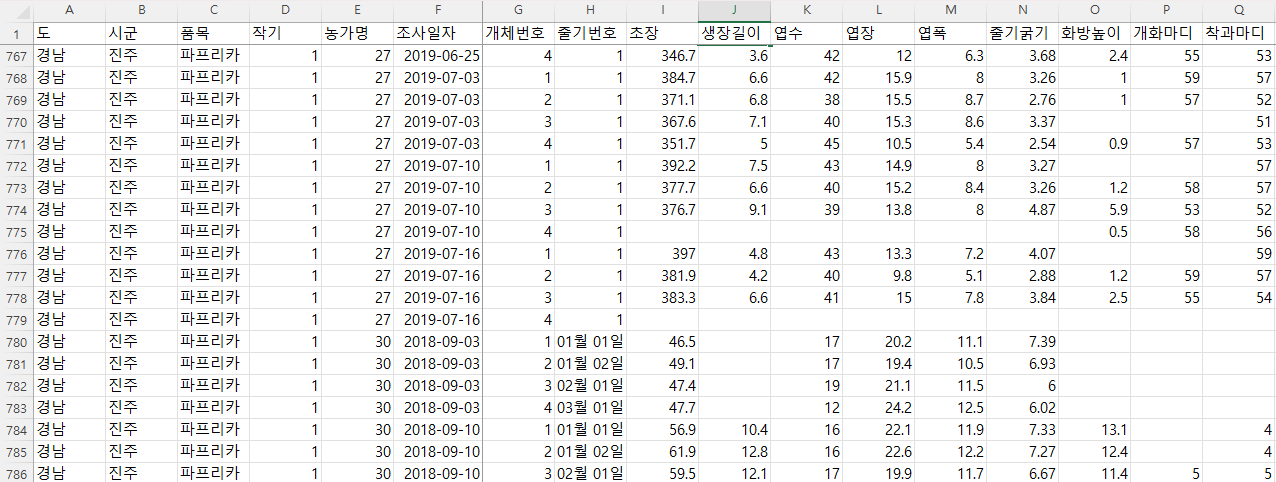

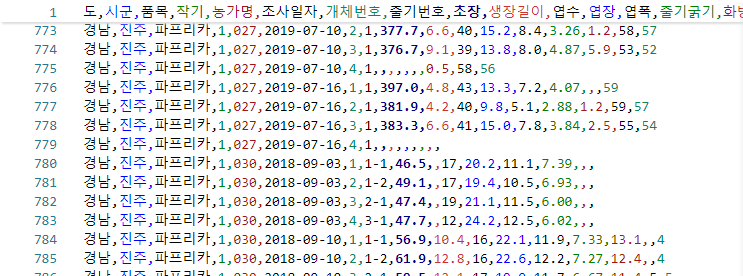

## 환경 데이터 분석

### 연도별 환경 데이터 취합

In [27]:
### 연도별 환경 데이터 취합
env_dfs = {}
for year in years:
    year_env_dfs = {k: v for k, v in data['환경'].items() if k.startswith(f"{year}_")}
    env_dfs[year] = pd.concat(list(year_env_dfs.values()), ignore_index=True)

print(env_dfs['2018'].columns)
env_dfs['2018'].head()

Index(['도', '시군', '품목', '작기', '농가명', '측정시간', '온도_외부', '풍향_외부', '풍속_외부',
       '일사량_외부', '누적일사량_외부', '강우감지', '온도_내부', '상대습도_내부', '잔존CO2', '토양온도'],
      dtype='object')


,도,시군,품목,작기,농가명,측정시간,온도_외부,풍향_외부,풍속_외부,일사량_외부,누적일사량_외부,강우감지,온도_내부,상대습도_내부,잔존CO2,토양온도
0,경기,고양,방울토마토,2,3,2018-08-14 00:00:00,26.7,276.0,0.0,5.0,NaN,0,27.9,83.5,548.0,29.9
1,경기,고양,방울토마토,2,3,2018-08-14 01:00:00,26.5,276.0,0.0,5.0,NaN,0,27.7,84.0,553.0,29.8
2,경기,고양,방울토마토,2,3,2018-08-14 02:00:00,26.5,276.0,0.0,5.0,NaN,0,27.8,84.6,568.0,29.6
3,경기,고양,방울토마토,2,3,2018-08-14 03:00:00,26.4,276.0,0.0,5.0,NaN,0,27.8,84.2,573.0,29.6
4,경기,고양,방울토마토,2,3,2018-08-14 04:00:00,26.4,276.0,0.0,5.0,NaN,0,27.6,85.3,557.0,29.5


### 연도별 품목 통계 계산 및 출력

In [43]:
for year in sorted(env_dfs.keys()):
    df = env_dfs[year]

    # 품목별 그룹화하여 고유값 개수 집계
    product_stats = df.groupby('품목').agg(
        시군=('시군', 'nunique'),
        작기=('작기', 'nunique'),
        농가=('농가명', 'nunique'),
        데이터=('농가명', 'count')
    ).reset_index()

    print(f"\n{year}년 품목별 고유값 개수:")
    display(product_stats.sort_values('품목'))


2018년 품목별 고유값 개수:


,품목,시군,작기,농가,데이터
0,딸기,22,1,60,322772
1,방울토마토,11,2,28,137372
2,오이,2,3,4,15703
3,완숙토마토,18,2,45,288531
4,참외,2,1,12,46226
5,파프리카,10,1,21,211234



2019년 품목별 고유값 개수:


,품목,시군,작기,농가,데이터
0,국화,1,3,3,18498
1,딸기,23,1,54,289678
2,방울토마토,11,3,31,166478
3,오이,5,4,14,49663
4,완숙토마토,21,2,42,253662
5,참외,2,1,14,74143
6,파프리카,10,1,29,206205



2020년 품목별 고유값 개수:


,품목,시군,작기,농가,데이터
0,국화,1,4,3,16213
1,딸기,20,1,51,270743
2,방울토마토,9,2,29,126205
3,오이,4,3,14,64958
4,완숙토마토,22,3,47,304893
5,참외,2,1,16,86545
6,파프리카,12,1,30,186267



2021년 품목별 고유값 개수:


,품목,시군,작기,농가,데이터
0,국화,2,3,3,12401
1,딸기,18,1,31,175064
2,방울토마토,8,3,25,142115
3,오이,4,3,16,63534
4,완숙토마토,14,2,28,170434
5,참외,2,1,21,100817
6,파프리카,10,1,13,162715


### 연도, 시군, 품목, 작기, 농가별 결측값 확인

In [44]:
for year in sorted(env_dfs.keys()):
    df = env_dfs[year]

    grouped = df.groupby(['시군', '품목', '작기', '농가명'])
    for name, group in grouped:
        print(f"\n{year}년, 시군: {name[0]}, 품목: {name[1]}, 작기: {name[2]}, 농가명: {name[3]}")
        print(group.info())


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
 11  강우감지      2915 non-null   int64         
 12  온도_내부     2759 non-null   float64       
 13  상대습도_내부   2759 non-null   float64       
 14  잔존CO2     2621 non-null   float64       
 15  토양온도      0 non-null      float64       
dtypes: datetime64[ns](1), float64(9), int64(3), object(3)
memory usage: 387.1+ KB
None

2020년, 시군: 화순, 품목: 방울토마토, 작기: 1, 농가명: 30
<class 'pandas.core.frame.DataFrame'>
Index: 3563 entries, 681012 to 684574
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   도         3563 non-null   object        
 1   시군        3563 non-null   object        
 2   품목        3563 non-null   object        
 3   작기        3563 non-null   int64         
 4   농가명       3563 non-null   int64         
 5   측정시간      3563 non-null   datetime64[ns]
 6   온도_외부     3563 non-null   float64       
 7   풍향_외부     0 non-null      float64       
 8   풍속_외부     3563 non-null   floa

### 연도, 시군, 품목, 작기, 농가별 통계 출력

In [30]:
for year in sorted(env_dfs.keys()):
    df = env_dfs[year]

    grouped = df.groupby(['시군', '품목', '작기', '농가명'])
    for name, group in grouped:
        print(f"\n{year}년, 시군: {name[0]}, 품목: {name[1]}, 작기: {name[2]}, 농가명: {name[3]}")

        exclude_columns = ['도', '시군', '품목', '작기', '농가명', '측정시간']
        remaining_columns = [col for col in group.columns if col not in exclude_columns]
        print(group[remaining_columns].describe())


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
75%      89.400000    NaN    24.700000  
max      97.000000    NaN    32.800000  

2020년, 시군: 평창, 품목: 파프리카, 작기: 1, 농가명: 1
             온도_외부  풍향_외부  풍속_외부  일사량_외부  누적일사량_외부    강우감지        온도_내부  \
count  1918.000000    0.0    0.0     0.0       0.0  1918.0  1918.000000   
mean     12.265902    NaN    NaN     NaN       NaN     0.0    22.634359   
std       6.777893    NaN    NaN     NaN       NaN     0.0     3.191426   
min      -4.700000    NaN    NaN     NaN       NaN     0.0    13.000000   
25%       6.800000    NaN    NaN     NaN       NaN     0.0    20.900000   
50%      12.900000    NaN    NaN     NaN       NaN     0.0    22.100000   
75%      17.575000    NaN    NaN     NaN       NaN     0.0    24.275000   
max      27.300000    NaN    NaN     NaN       NaN     0.0    34.800000   

           상대습도_내부        잔존CO2  토양온도  
count  1918.000000  1766.000000   0.0  
mean     83.479041   480.493205   NaN  
std      10.732072   188.808252   NaN  
min   

### 환경 데이터 전처리

#### 환경 데이터 누락 열 제거

In [31]:
# 결과를 저장할 빈 리스트 생성
result_dfs = []

for year in sorted(env_dfs.keys()):
    df = env_dfs[year].copy()

    # 측정시간을 연-월-일-시간 단위로 처리
    if '측정시간' in df.columns:
        if not pd.api.types.is_datetime64_any_dtype(df['측정시간']):
            df['측정시간'] = pd.to_datetime(df['측정시간'])

        # 측정시간에서 연-월-일-시간 추출
        df['연'] = df['측정시간'].dt.year
        df['월'] = df['측정시간'].dt.month
        df['일'] = df['측정시간'].dt.day
        df['시간'] = df['측정시간'].dt.hour

    grouped = df.groupby(['시군', '품목', '작기', '농가명'])
    for name, group in grouped:
        print(f"\n{year}년, 시군: {name[0]}, 품목: {name[1]}, 작기: {name[2]}, 농가명: {name[3]}")
        exclude_columns = ['측정시간', '연', '월', '일', '시간', '시군', '품목', '작기', '농가명']

        # 각 컬럼별 데이터 개수 확인
        column_counts = group.count()
        # 데이터 개수가 0인 컬럼 식별
        zero_count_columns = [col for col in group.columns
                             if col not in exclude_columns and column_counts[col] == 0]
        # 데이터 개수가 0인 컬럼을 제외한 나머지 컬럼
        valid_columns = [col for col in group.columns
                        if col not in exclude_columns and col not in zero_count_columns]
        valid_columns.append('측정시간')

        # 유효한 컬럼만 포함하는 데이터프레임 생성 및 정보 출력
        valid_df = group[valid_columns].copy()
        print(valid_df.info())

        # 그룹 정보 추가
        valid_df['연도'] = year
        valid_df['시군'] = name[0]
        valid_df['품목'] = name[1]
        valid_df['작기'] = name[2]
        valid_df['농가명'] = name[3]

        # 결과 리스트에 추가
        result_dfs.append(valid_df)

# 모든 데이터프레임 병합
env_df = pd.concat(result_dfs, ignore_index=True)
print(env_df.head())

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
 9   토양온도      8243 non-null   float64       
 10  측정시간      8245 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 773.0+ KB
None

2020년, 시군: 장흥, 품목: 파프리카, 작기: 1, 농가명: 18
<class 'pandas.core.frame.DataFrame'>
Index: 279 entries, 597832 to 598110
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   도         279 non-null    object        
 1   온도_외부     279 non-null    float64       
 2   누적일사량_외부  278 non-null    float64       
 3   강우감지      279 non-null    int64         
 4   온도_내부     279 non-null    float64       
 5   상대습도_내부   278 non-null    float64       
 6   잔존CO2     278 non-null    float64       
 7   측정시간      279 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 19.6+ KB
None

2020년, 시군: 장흥, 품목: 파프리카, 작기: 1, 농가명: 20
<class 'pandas.core.frame.DataFrame'>
Index: 793

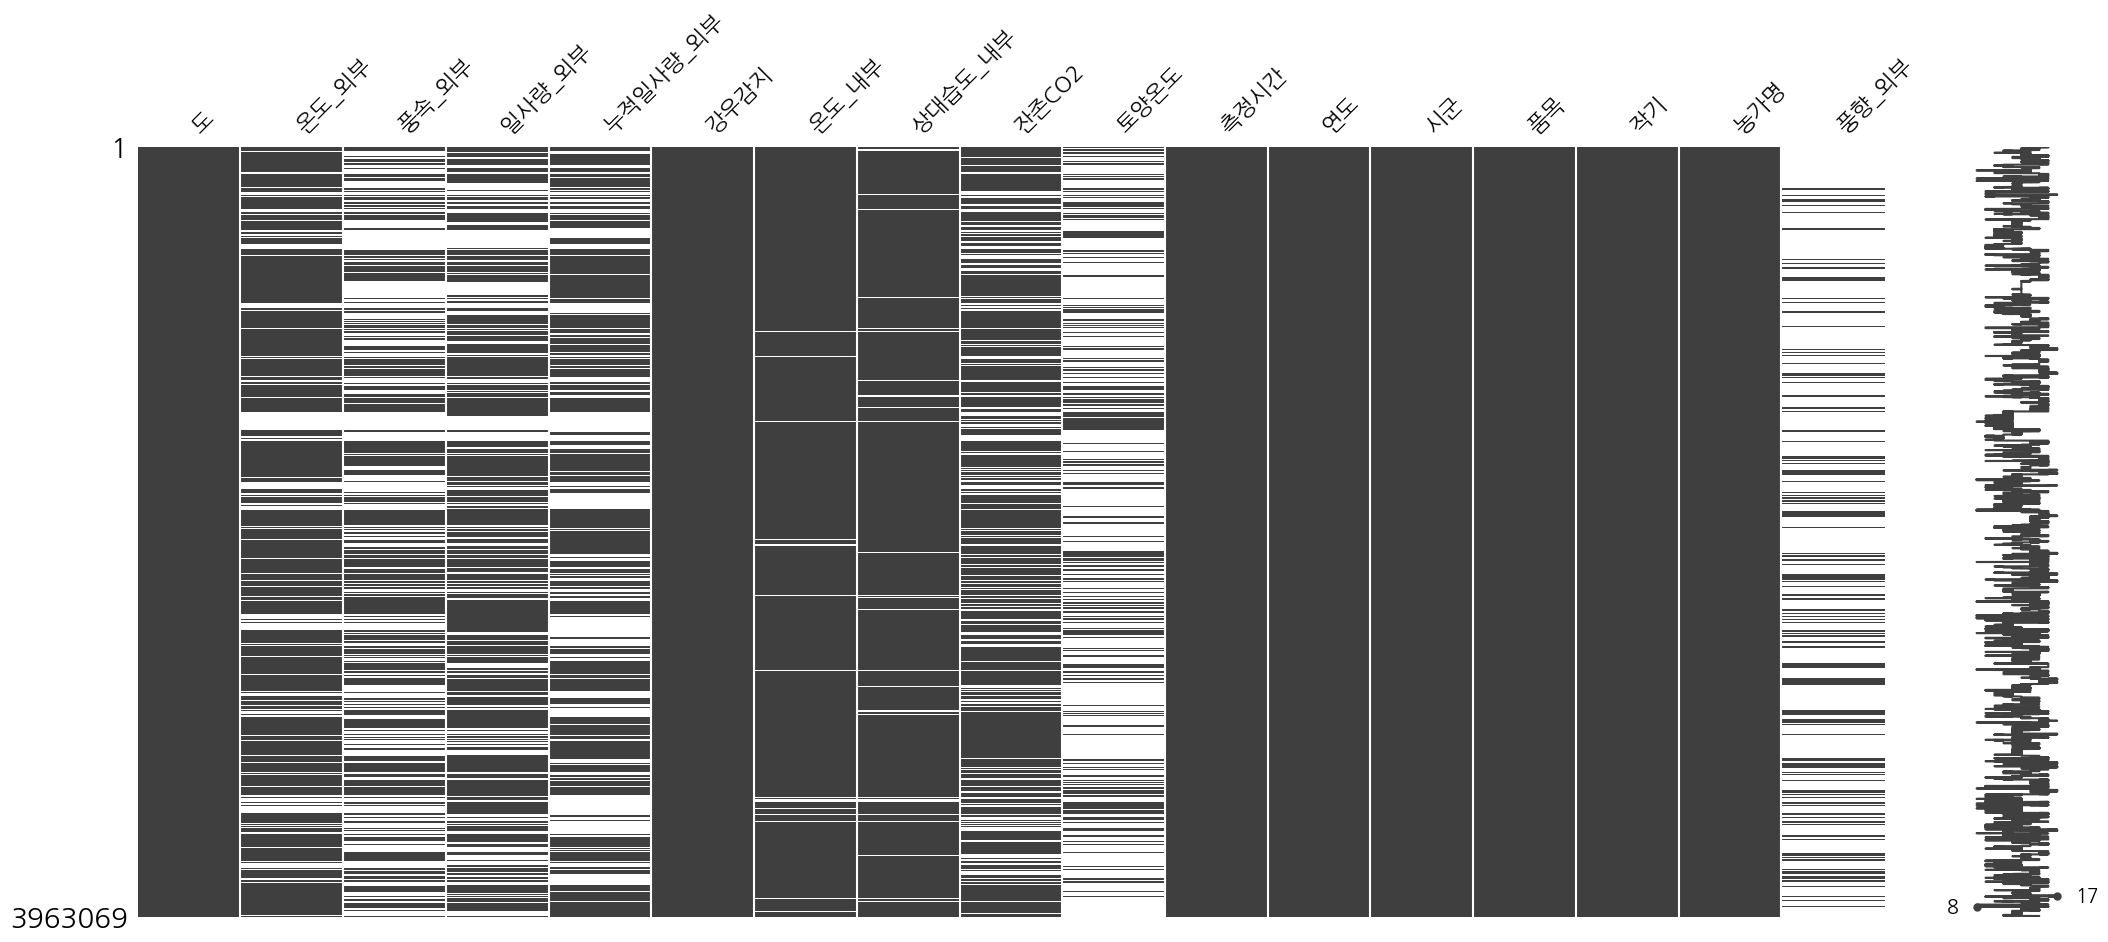

In [32]:
import missingno as msno

msno.matrix(env_df);

#### 환경 데이터 누락 항목 보간(선형) - 온도_내부, 상대습도_내부

In [33]:
env_filled_df = env_df.copy()
env_filled_df[['온도_내부', '상대습도_내부']] = env_df[['온도_내부', '상대습도_내부']].ffill()
env_filled_df.head()

,도,온도_외부,풍속_외부,일사량_외부,누적일사량_외부,강우감지,온도_내부,상대습도_내부,잔존CO2,토양온도,측정시간,연도,시군,품목,작기,농가명,풍향_외부
0,전남,24.3,0.0,0.0,2297.0,0,25.5,99.5,435.0,25.1,2018-08-29 00:00:00,2018,강진,딸기,1,41,NaN
1,전남,23.6,0.0,0.0,2297.0,0,25.3,99.8,443.0,24.9,2018-08-29 01:00:00,2018,강진,딸기,1,41,NaN
2,전남,23.0,0.0,0.0,2297.0,0,25.2,100.0,462.0,24.9,2018-08-29 02:00:00,2018,강진,딸기,1,41,NaN
3,전남,22.5,0.0,0.0,2297.0,0,24.8,100.0,469.0,24.7,2018-08-29 03:00:00,2018,강진,딸기,1,41,NaN
4,전남,22.1,0.0,0.0,2297.0,0,24.2,99.8,477.0,24.4,2018-08-29 04:00:00,2018,강진,딸기,1,41,NaN


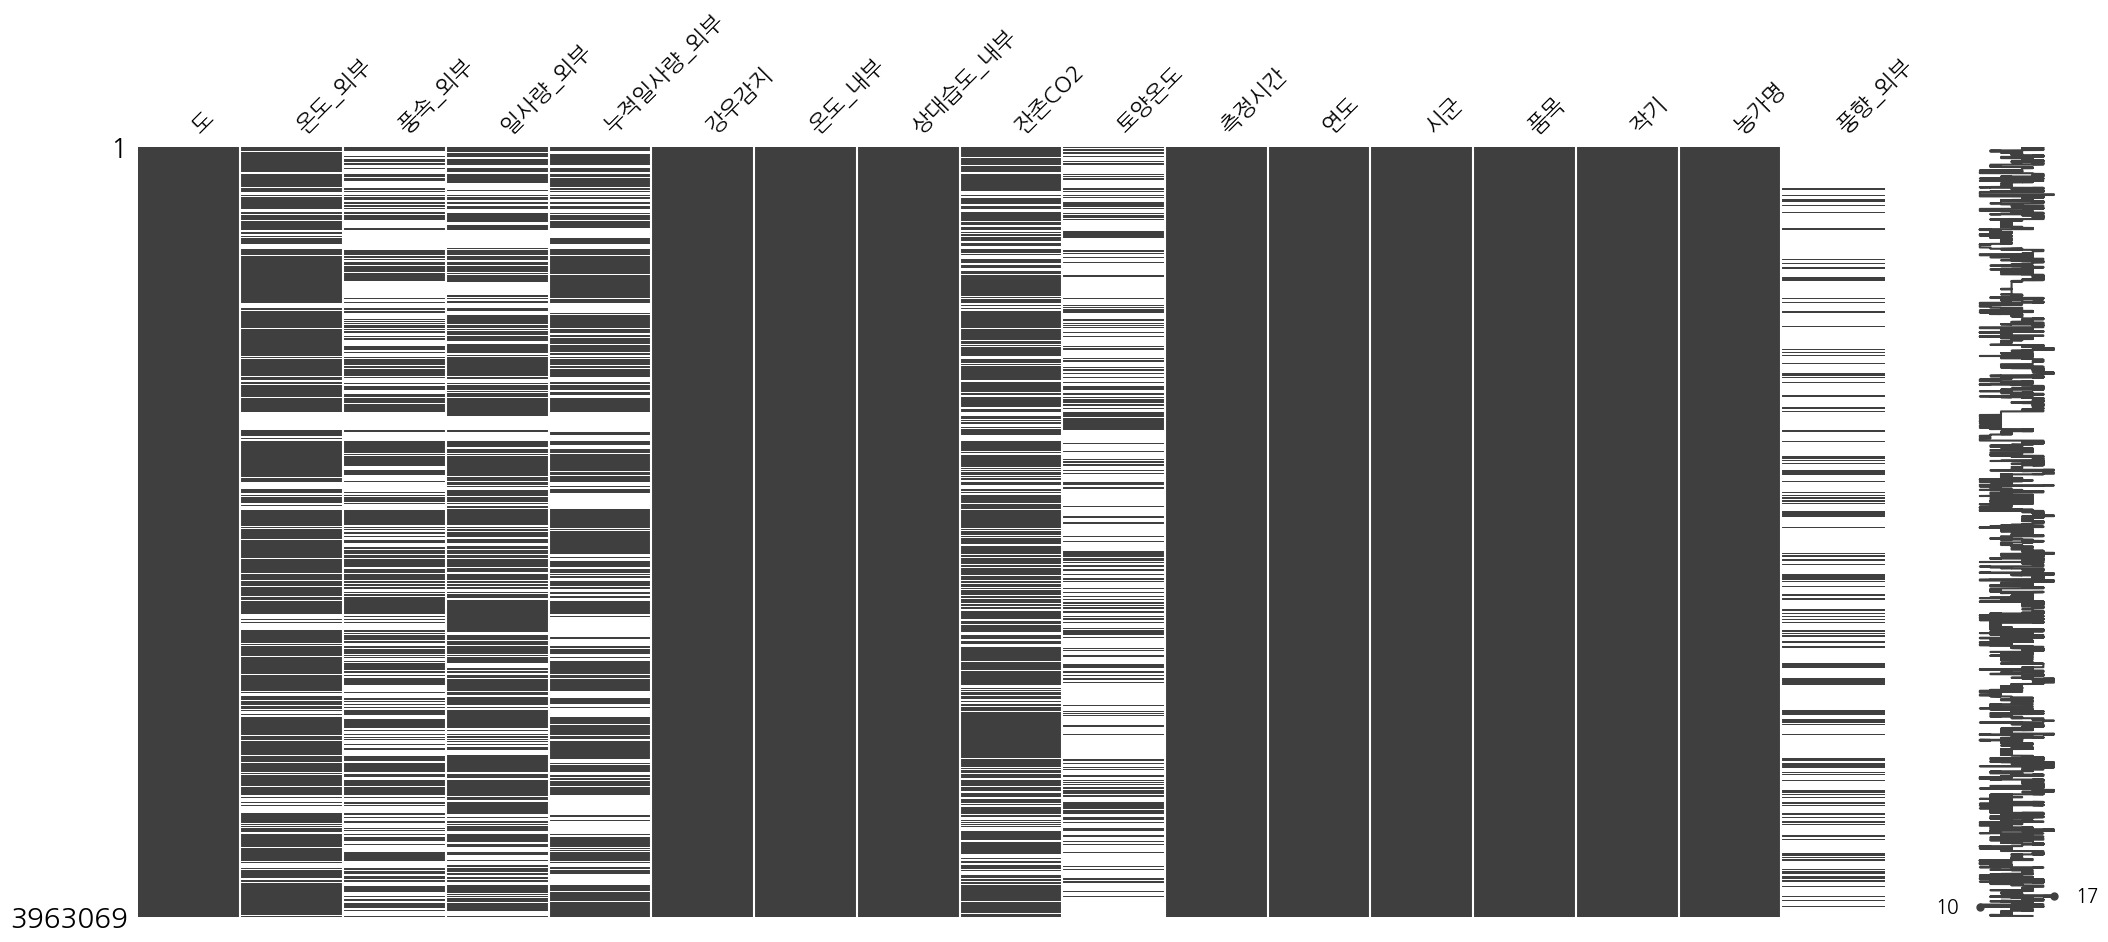

In [34]:
msno.matrix(env_filled_df);

### 완숙토마토 농가 환경 데이터 시각화

In [35]:
print(env_filled_df[env_filled_df['품목'] == '완숙토마토']['시군'].unique())
print(env_filled_df[env_filled_df['품목'] == '완숙토마토']['작기'].unique())
print(env_filled_df[env_filled_df['품목'] == '완숙토마토']['농가명'].unique())

['강진' '고흥' '광주' '군산' '김제' '김해' '담양' '보성' '사천' '완주' '익산' '장성' '장수' '정읍'
 '진안' '창녕' '함안' '화순' '상주' '장흥' '춘천' '평창' '평택' '화천' '고양' '오산']
[1 2 3]
[43 38  2 12 11 14 15 22 23 31 56 42 34 45 49 50 53 57 58 10 13 27 33 16
 17 18 20 25 26 28 30 29 32  9 24 51 54 59 52 55 39 40 41 44 60 35  4  5
  1 48 37 21 19 46  6  7  3 47 36  8]


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

tomato_env = env_filled_df[(env_filled_df['품목'] == '완숙토마토') & (env_filled_df['시군'] == '평창') & (env_filled_df['작기'] == 1)]

print('농가명:', tomato_env['농가명'].unique())

농가명: [ 7  6 10  8 11 13]


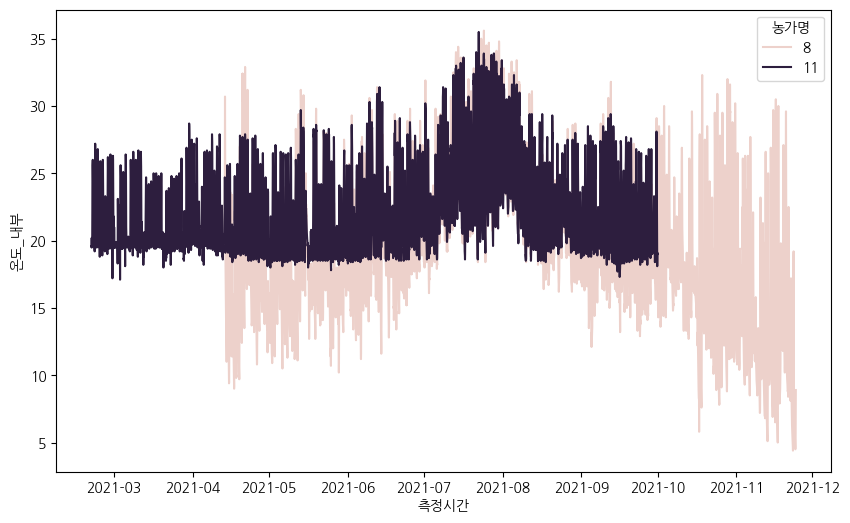

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=tomato_env[(tomato_env['농가명'] == 11) | (tomato_env['농가명'] == 8)], x='측정시간', y='온도_내부', hue='농가명')
plt.show()

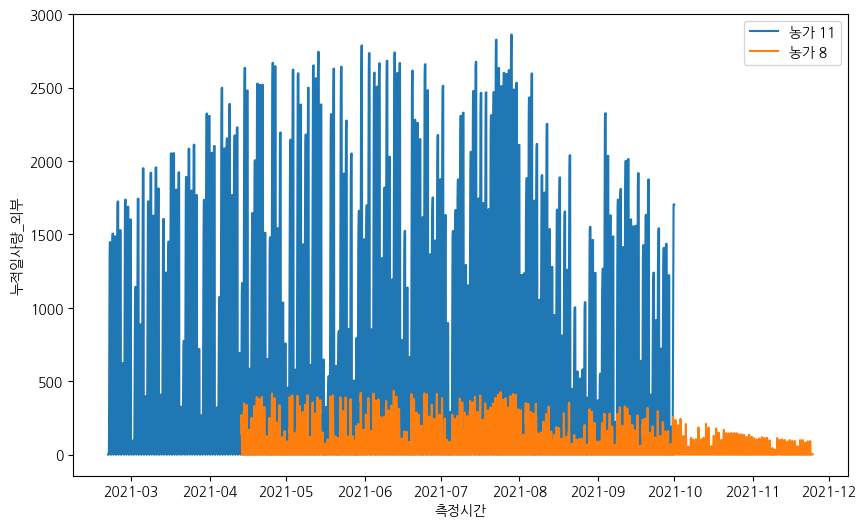

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=tomato_env[(tomato_env['농가명'] == 11)], x='측정시간', y='누적일사량_외부', label='농가 11')
sns.lineplot(data=tomato_env[(tomato_env['농가명'] == 8)], x='측정시간', y='누적일사량_외부', label='농가 8')
plt.show()

In [39]:
print(tomato_env.columns)

Index(['도', '온도_외부', '풍속_외부', '일사량_외부', '누적일사량_외부', '강우감지', '온도_내부', '상대습도_내부',
       '잔존CO2', '토양온도', '측정시간', '연도', '시군', '품목', '작기', '농가명', '풍향_외부'],
      dtype='object')


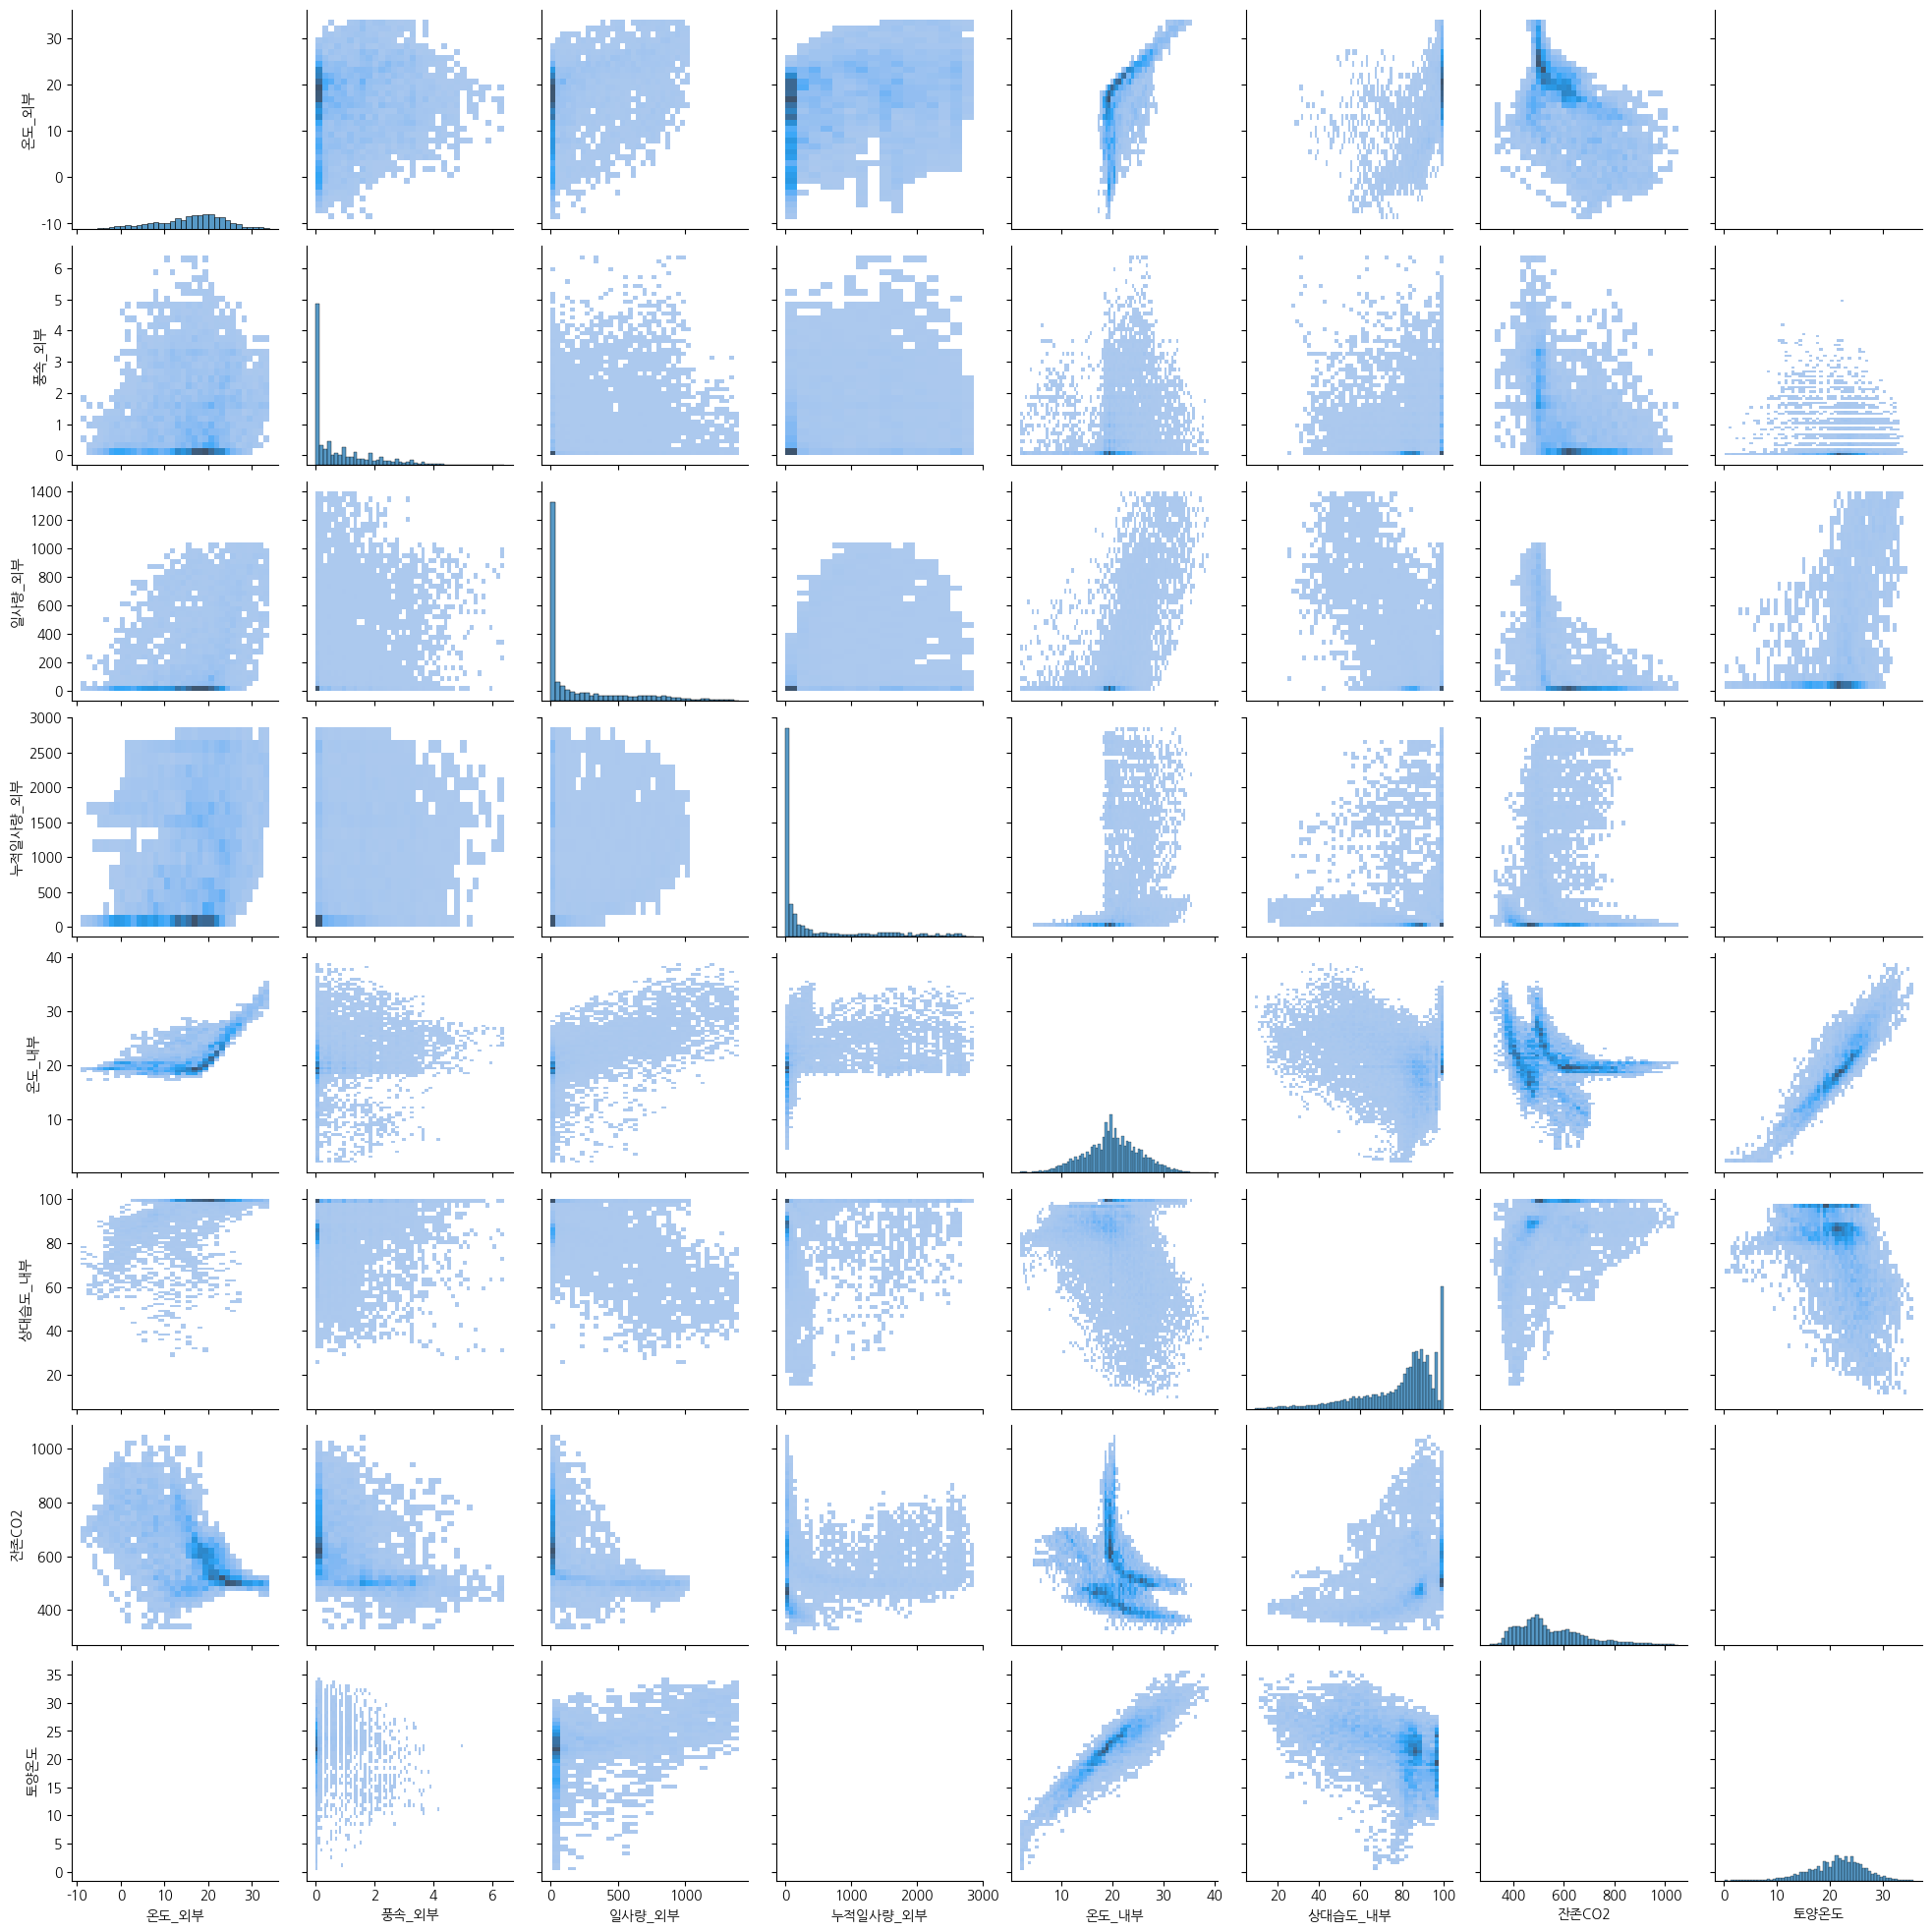

In [40]:
# tomato_env.columns
# fig, ax = plt.subplots(figsize=(10, 6))
sns.pairplot(tomato_env[['온도_외부', '풍속_외부', '일사량_외부', '누적일사량_외부', '온도_내부', '상대습도_내부', '잔존CO2', '토양온도']], kind="hist")
plt.show()

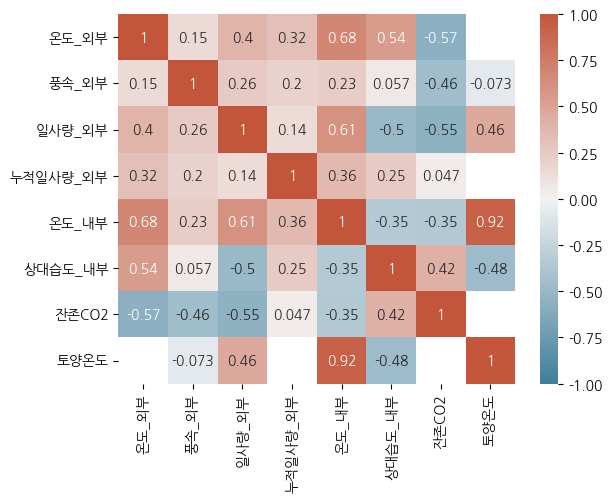

In [41]:
corr = tomato_env[['온도_외부', '풍속_외부', '일사량_외부', '누적일사량_외부', '온도_내부', '상대습도_내부', '잔존CO2', '토양온도']].corr()
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values,
            cmap=cmap, vmax=1.0, vmin=-1.0, annot=True);

## 생육 데이터

In [42]:
### 연도별 환경 데이터를 취합
growth_dfs = {}
for year in years:
    year_growth_dfs = {k: v for k, v in data['생육'].items() if k.startswith(f"{year}_")}
    growth_dfs[year] = pd.concat(list(year_growth_dfs.values()), ignore_index=True)

crop = '완숙토마토'

growth_filtered = growth_dfs[year][(growth_dfs[year]['품목'] == crop)]
print(growth_filtered['시군'].unique())

['평창' '화천' '광주' '오산' '평택' '김해' '사천' '창녕' '함안' '상주' '강진' '담양' '보성' '화순']


In [ ]:
growth_site_filtered = growth_filtered[growth_filtered['시군'] == '평창']
growth_site_filtered.head()

,도,시군,품목,작기,농가명,조사일자,개체번호,초장,엽장,엽폭,...,분지수,줄기중앙직경,개화시,개화마디,착과마디,액아구분,엽병장,관부직경,개화군,착과군
55369,강원,평창,완숙토마토,1,8,2021-05-11,1,68.0,51.0,52.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6,0.2
55370,강원,평창,완숙토마토,1,8,2021-05-11,2,62.0,55.0,54.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
55371,강원,평창,완숙토마토,1,8,2021-05-11,3,64.0,49.0,54.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.5
55372,강원,평창,완숙토마토,1,8,2021-05-11,4,69.0,43.0,46.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
55373,강원,평창,완숙토마토,1,8,2021-05-18,1,84.0,45.0,42.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.6


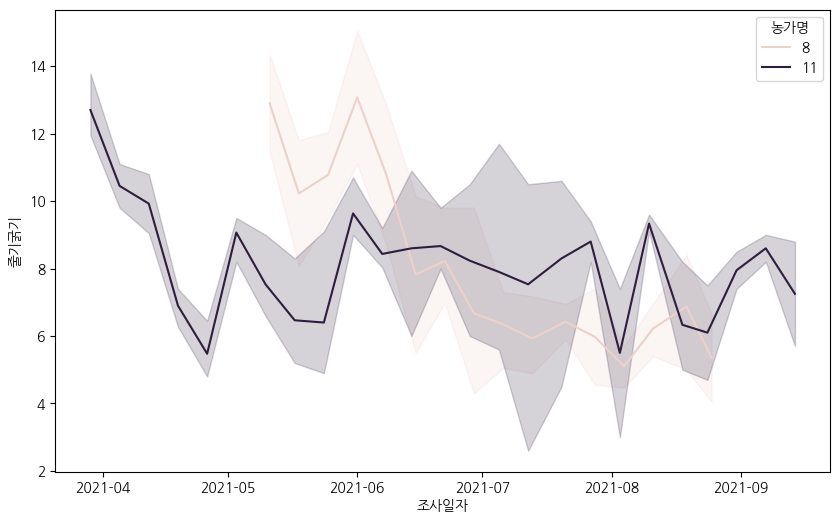

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=growth_site_filtered[(growth_site_filtered['농가명'] == 11) | (growth_site_filtered['농가명'] == 8)], x='조사일자', y='줄기굵기', hue='농가명')
plt.show()

## 생산 데이터

In [ ]:
### 연도별 환경 데이터를 취합
yield_dfs = {}
for year in years:
    year_yield_dfs = {k: v for k, v in data['생산'].items() if k.startswith(f"{year}_")}
    yield_dfs[year] = pd.concat(list(year_yield_dfs.values()), ignore_index=True)

crop = '완숙토마토'

yield_filtered = yield_dfs[year][(yield_dfs[year]['품목'] == crop)]
print(yield_filtered['시군'].unique())

['평창' '화천' '광주' '오산' '평택' '김해' '사천' '창녕' '함안' '상주' '강진' '화순']


In [ ]:
yield_site_filtered = yield_filtered[yield_filtered['시군'] == '평창']
yield_site_filtered.head()

,도,시군,품목,작기,농가명,출하일자,총출하량,판매금액
5067,강원,평창,완숙토마토,1,8,2021-06-22,124.0,NaN
5068,강원,평창,완숙토마토,1,8,2021-06-22,76.0,NaN
5069,강원,평창,완숙토마토,1,8,2021-06-22,30.0,NaN
5070,강원,평창,완숙토마토,1,8,2021-06-22,35.0,NaN
5071,강원,평창,완숙토마토,1,8,2021-06-23,5.0,NaN


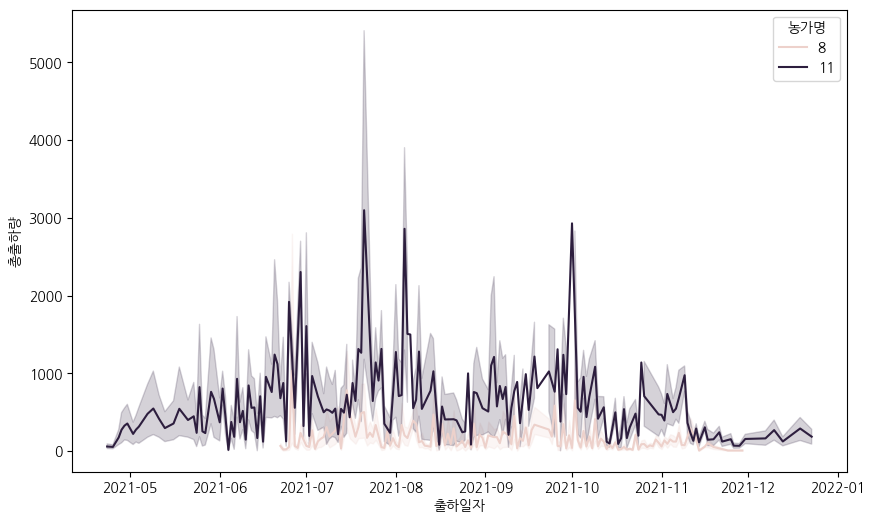

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=yield_site_filtered[(yield_site_filtered['농가명'] == 11) | (yield_site_filtered['농가명'] == 8)], x='출하일자', y='총출하량', hue='농가명')
plt.show()